In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!pip install PyShp

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [9]:
#-73.58583, 45.52807, -73.55183, 45.49207

Enter the gridsize value: 0.002
[[-73.55952174  45.51703069]
 [-73.5550998   45.52184773]
 [-73.58359279  45.49011962]
 ...
 [-73.57925846  45.49382111]
 [-73.57925846  45.49382111]
 [-73.57964441  45.52389835]]
Standard Deviation: 47.7950245841552
Average: 47.525
Enter the threshold value(1-100): 75
Start (-73.5858307015, 45.52806850850005) End (-73.55183070150008, 45.492068508500004)
A* Search took: 0.05227947235107422 seconds ---
Path found


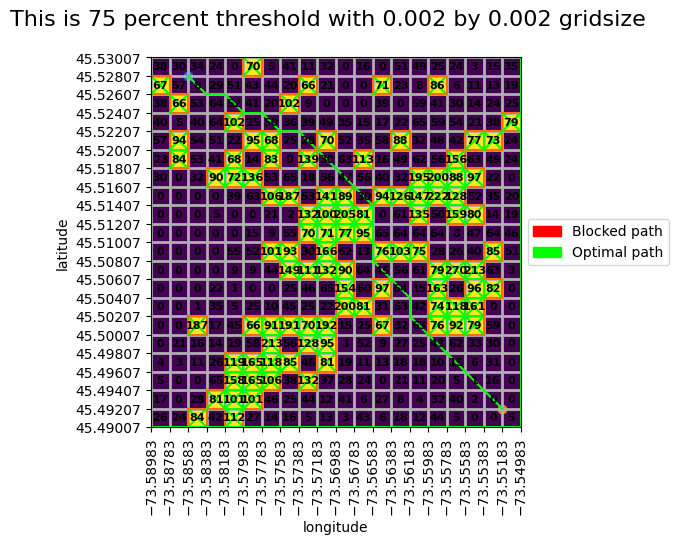

In [40]:
import matplotlib.patches as mpatches
import shapefile
import matplotlib.pyplot as plt
import numpy as np
import time
import math

class grid_box(object):
    '''
    Each grid box contain 4 coordinates, 6 lines and box value after set threshold
    '''
    def __init__(self, p1,p2,p3,p4,value):
        self.p1=p1
        self.p2=p2
        self.p3=p3
        self.p4=p4
        self.value=value
        self.lines=[]
        self.__setlines__()
        
    def __checkdiagonal__(self,a,b): #check if a line in a box is diagonal
        if format(abs(a[0] -b[0]), '.1g') == format(abs(a[1] -b[1]), '.1g'):
            return True
        else:
            return False
    def __setlines__(self):#create all lines in a box
        if self.value==0:
            for i in self.get_all_coordinates():
                for j in self.get_all_coordinates():
                    if not np.array_equal(i, j):
                        if self.__checkdiagonal__(i,j):
                            self.lines.append(line(i,j, 1.5))
                        else:
                            self.lines.append(line(i,j, 1))
        else :
            self.lines.append(line(self.p1, self.p2, 1000))
            self.lines.append(line(self.p2, self.p3, 1000))
            self.lines.append(line(self.p3, self.p4, 1000))
            self.lines.append(line(self.p4, self.p1, 1000))
            self.lines.append(line(self.p3, self.p1, 1000))
            self.lines.append(line(self.p2, self.p4, 1000))

    def get_all_lines(self):#get all lines for a grid box
        return self.lines
    def get_all_coordinates(self):#get all coordinates for a grid box
        return [self.p1,self.p2,self.p3,self.p4]
    
    
    
class line(object):
    '''
    Each line contain 2 coordinates,weight of the line and bool to see if the line is passable
    '''
    def __init__(self, p1,p2,weight=None):
        self.p1=p1
        self.p2=p2
        self.weight=weight
        self.passable=self.__isPassable__()
    def is_boundaryline(self,a):#check if a line is on the edge of the grid
        if bool(set(a).intersection(set(self.p1))) and bool(set(a).intersection(set(self.p2))):
            return True
        else:
            return False
        
    def is_diagonal(self): #check if line is a diagonal
        if format(abs(self.p1[0] -self.p2[0]), '.1g') == format(abs(self.p1[1] -self.p2[1]), '.1g'):
            return True
        else:
            return False
    def get_coordinate(self):#get coordinates of line p1,p2
        return [self.p1,self.p2]
    
    def get_invcoordinate(self):#get reverse coordinates of line p2,p1
        return [self.p2,self.p1]
    
    def checkpoint(self,point):#check if a given coordinate is on a line
        if format(abs(point[0] -self.p1[0]), '.3f') == format(0, '.3f') and format(abs(point[1] -self.p1[1]), '.3f')  == format(0, '.3f') :
#             print(format(point[0] -self.p1[0], '.3f'),format(point[1] -self.p1[1], '.3f'))
            return True
        elif format(abs(point[0] -self.p2[0]), '.3f')  == format(0, '.3f') and format(abs(point[1] -self.p2[1]), '.3f')== format(0, '.3f') :
            return True
        else:
            return False
    def neighbour(self,point):#give coordinate of the other end of the line
        if tuple(self.p1)==point:
            return tuple(self.p2 )
        elif tuple(self.p2)==point:
            return tuple(self.p1 )
        
    def __isPassable__(self): #check if a line is passable
        if self.weight == 1000:
            return False
        elif self.weight == 1.3:
            return True
        elif self.weight == 1.5:
            return True  
        elif self.weight == 1:
            return True 
        else:
            return False


    def set_Weight(self,weight):
        self.weight=weight
        self.passable=self.__isPassable__()
'''
 lowest node is gottent by smallest f(n)
'''        
def lowest_node(nodes,points,lines,g_values):
    nodes=list(nodes) 
    current_node = nodes[0]
    for  item in nodes:
#         print(item,current_node,g_values[current_node] )
        if g_values[item]['fvalue'] <= g_values[current_node]['fvalue']:
            current_node = item
    return current_node
'''
 constructing path back from goal
'''   
def construct_path(current,g_values):
    #get the path
    path={current}
    draw=[]
    temp=current 
#     print(g_values[current])
    #assigning weight of optimal path to 0
    while g_values[temp]['previous']:
        new_line=tuple([temp,g_values[temp]['previous']])
        invnew_line=tuple([g_values[temp]['previous'],temp])
        if  new_line in lines.keys(): 
            lines[ new_line].set_Weight(0)
        elif invnew_line in lines.keys():
            lines[invnew_line].set_Weight(0)
        path.add(temp)
        draw.append(new_line)
        temp = g_values[temp]['previous']
    return ('Path found')                

'''
Heuristic Search 
'''
def heuristics(start_point,end_point,lines,points):
    start_time = time.time()
    g_values={tuple(start_point ): {'weight':0,'previous':None,'fvalue':0}}
    open_set={tuple(start_point )}
    closed_set=[]
    
    h_value = lambda a , b: math.sqrt(((a[0]+b[0])**2)+ ((a[1]+b[1])**2)) 
#     h_value = lambda a , b: abs(a[0]-b[0])+ abs(a[1]-b[1])
    while len(open_set) >0:
        #end if search time is more than 10 secs
        if (time.time() - start_time)>10:
            print(f"A* Search took: {time.time() - start_time} seconds ---" )  
            return ('Time is up. The optimal path is not found.')
        current = lowest_node(open_set,points,lines,g_values)
        #end if final destination has been reached
        if current == tuple(end_point ):
            print(f"A* Search took: {time.time() - start_time} seconds ---" )  
            return construct_path(current,g_values)
  
        open_set.remove(current) 
        closed_set.append(current)
        for line_key in points[current]:
            if lines[line_key].passable: #allow if line is not a blocked path
                if lines[line_key].neighbour(current) in closed_set:
                    continue
                else:
                    tempH= lines[line_key].weight + g_values[current]['weight'] 
                    if lines[line_key].neighbour(current) in open_set: #if its already in open set, checking if g(n) is better
                        if g_values[lines[line_key].neighbour(current)]['weight']>=tempH:
                            g_values[lines[line_key].neighbour(current)]['weight']=tempH
                            g_values[lines[line_key].neighbour(current)]['previous']=current
                    else:
                        open_set.add(lines[line_key].neighbour(current))
    #                     print(tempH)
                        g_values[lines[line_key].neighbour(current)]={'weight': tempH ,'previous':current}
                      
                      
    #             f(n):= g(n) + h(n)
                    g_values[lines[line_key].neighbour(current)]['fvalue']= h_value(lines[line_key].neighbour(current),end_point)+g_values[lines[line_key].neighbour(current)]['weight']
  
    # Open set is empty but goal was found
    print(f"A* Search took: {time.time() - start_time} seconds ---" )  
    return ('Due to blocks, no path is found. Please change the map and try again')

     
if __name__ == '__main__':
    sf = shapefile.Reader("/content/drive/MyDrive/crime_dt.shp")
    shapes = sf.shapes()
    gridsize = float(input("Enter the gridsize value: ")) 
    data = np.array([ x.points[0] for x in shapes])  # getting x,y coordinates in a list
    print(data)
    x, y = data.T
    #setting axis
    axes = plt.axes()
    axes.set_yticks(np.arange(min(y), max(y) + gridsize, gridsize))
    axes.set_xticks(np.arange(min(x), max(x) + gridsize, gridsize))
    # using histogram2d allows you to plot a 2d array based on their positions. bin is how you set the area of your graph 
    H, xedges, yedges = np.histogram2d(x, y, bins=(np.arange(min(x), max(x) + gridsize, gridsize), np.arange(min(y), max(y) + gridsize, gridsize)))
    # if xedges > yedges:
    #     xedges = yedges
    # if yedges > xedges:
    #     yedges = xedges
    H = H.T  # Let each row list bins with common y range.
    
#     print(H.shape)#count per grid
    print(f'Standard Deviation: {np.std(H)}')
    print(f'Average: {np.mean(H)}')
    grid_coordinate=np.array([[[x,y] for x in xedges] for y in yedges])#getting all grid coordinates
#     print(grid_coordinate.shape)
    
    '''
    getting threshold value and playing 
    '''    
    threshold = int(input("Enter the threshold value(1-100): ")) 

    if threshold !=0:
        temp = np.where(H >= np.percentile(H, threshold), np.max(H),0)
    elif threshold ==0:
        temp = H
        temp = np.where(H > np.percentile(H, threshold), 1,0)
    #     temp[temp np.percentile(H, i)] = 0
    plt.imshow(temp,interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])       
      
    '''
    creating an array of class grid_box to store all the boxes in the grid with their coordinates
    '''            
    gridboxes=[]
    for x in range(H.shape[0]):
        temparr=[]
        for y in range(H.shape[1]): 
            temparr.append(grid_box(grid_coordinate[x][y],grid_coordinate[x+1][y],grid_coordinate[x][y+1],grid_coordinate[x+1][y+1],temp[x][y]))
        gridboxes.append(temparr)
    
    '''
    getting all lines on the graph
    '''     
    lines={} 
    for i in range(len(gridboxes)):
        for j in range(len(gridboxes[i])):
            for line in gridboxes[i][j].get_all_lines():
                if tuple(map(tuple, line.get_coordinate())) in lines.keys():
                    if not line.is_diagonal():
                        if  line.is_boundaryline([np.max(xedges),np.min(xedges),np.max(yedges),np.min(yedges)]):
                            line.set_Weight(1000)
                    if line.weight!=lines.get(tuple(map(tuple, line.get_coordinate()))).weight and lines[tuple(map(tuple, line.get_coordinate()))].weight!=1.3:
#                         print(line.weight,lines.get(tuple(map(tuple, line.get_coordinate()))).weight)
                        lines[tuple(map(tuple, line.get_coordinate()))].set_Weight(1.3)
                elif tuple(map(tuple, line.get_invcoordinate())) in lines.keys() :
                    if not line.is_diagonal():
                        if  line.is_boundaryline([np.max(xedges),np.min(xedges),np.max(yedges),np.min(yedges)]):
                            line.set_Weight(1000)
                    if line.weight!=lines[tuple(map(tuple, line.get_invcoordinate()))].weight and lines[tuple(map(tuple, line.get_invcoordinate()))].weight!=1.3:
#                         print(line.weight,lines.get(tuple(map(tuple, line.get_invcoordinate()))).weight)
                        lines[tuple(map(tuple, line.get_invcoordinate()))].set_Weight(1.3)
                else:
#                     print(tuple(map(tuple, line.get_coordinate())))
                    lines[tuple(map(tuple, line.get_coordinate()))]=line
                    if not line.is_diagonal():
                        if  line.is_boundaryline([np.max(xedges),np.min(xedges),np.max(yedges),np.min(yedges)]):
                            line.set_Weight(1000)
#                 if not line.passable:
#                     print(line.get_coordinate(),line.weight,line.passable)

    '''
    getting all points on the graph
    ''' 
    points={}
    for x in range(len(xedges)):
        for y in range(len(yedges)): 
#             print(tuple(grid_coordinate[x][y]))
            for key,linevalue in lines.items():
#                 print(key,linevalue)
                if linevalue.checkpoint(grid_coordinate[x][y]):
                    if tuple(grid_coordinate[x][y]) in points.keys():
#                         print('exist')
                        points[tuple(grid_coordinate[x][y])].add(key)
                    else:
                        points[tuple(grid_coordinate[x][y])]={key}
                else:
                    pass


    
     
    x1_coordinate = -73.58583
    y1_coordinate = 45.52807
    x2_coordinate = -73.55183
    y2_coordinate = 45.49207
#     x1_coordinate = float(-73.575) 
#     y1_coordinate = float(45.496) 
#     x2_coordinate = float(-73.557) 
#     y2_coordinate = float(45.51) 
    x1_index=np.where(np.absolute(xedges-x1_coordinate) == np.min(np.absolute(xedges-x1_coordinate)))
    y1_index=np.where(np.absolute(yedges-y1_coordinate) == np.min(np.absolute(yedges-y1_coordinate)))
    x2_index=np.where(np.absolute(xedges-x2_coordinate) == np.min(np.absolute(xedges-x2_coordinate)))
    y2_index=np.where(np.absolute(yedges-y2_coordinate) == np.min(np.absolute(yedges-y2_coordinate)))
    start_point=(xedges[x1_index[0]][0], yedges[y1_index[0]][0])
    end_point=(xedges[x2_index[0]][0], yedges[y2_index[0]][0])
    plt.scatter (xedges[x1_index[0]][0], yedges[y1_index[0]][0])
    plt.scatter (xedges[x2_index[0]][0], yedges[y2_index[0]][0])

    print('Start',start_point,'End',end_point)
    print(heuristics(start_point,end_point,lines,points)) 
             
    '''
    Final part for plotting
    '''
    render_time = time.time() 
    for line in lines.values():
        line_x = np.linspace(line.get_coordinate()[0][0], line.get_coordinate()[1][0])
        line_y = np.linspace(line.get_coordinate()[0][1], line.get_coordinate()[1][1])
        if line.weight == 0:
            plt.plot(line_x, line_y, color=[0, 1, 0])
            '''
            uncomment lines below to see them coloured. line was commented out due to added secs to time 
            '''
#         elif line.weight == 1:
#             plt.plot(line_x, line_y, color='#00aeff')    
        elif line.weight == 1.3 :
            plt.plot(line_x, line_y, color='#fc6f03')
#         elif line.weight == 1.5:
#             plt.plot(line_x, line_y, color='#ffa600')   
        elif not line.passable:
            plt.plot(line_x, line_y, color=[0, 1, 0])   
#         else:
#             plt.plot(line_x, line_y, color=[1, 0, 0])
            
         
    plt.grid( linewidth=2)
    plt.setp(axes.get_xticklabels(), rotation=90)
    plt.suptitle(f'This is {threshold} percent threshold with {gridsize} by {gridsize} gridsize', fontsize=16)
    plt.xlabel('longitude')
    plt.ylabel('latitude')
    a = mpatches.Patch(color=[1, 0, 0], label='Blocked path')
    b = mpatches.Patch(color=[0, 1, 0], label='Optimal path')
    # c = mpatches.Patch(color='#00aeff', label='1.0 weighted lines')
    # d = mpatches.Patch(color='#ff00fb', label='1.3 weighted lines')#ff00f7
    # e = mpatches.Patch(color='#ffa600', label='1.5 weighted lines')
    plt.legend(handles=[a,b], loc='center left', bbox_to_anchor=(1, 0.5))
       
    for i in range(len(yedges)-1):
        for j in range(len(xedges)-1):
            plt.text(xedges[j]+(gridsize/2),yedges[i]+(gridsize/2), int(H.T[j,i]), 
                     color="#000000", ha="center", va="center", fontweight="bold",
                     fontsize=8)
            


def djheuristics(start_point, end_point, lines, points):
    start_time = time.time()
    g_values = {tuple(start_point): {'weight': 0, 'previous': None, 'fvalue': 0}}
    open_set = {tuple(start_point)}
    closed_set = []

    # Modify h_value to always return 0
    h_value = lambda a, b: 0

    while len(open_set) > 0:
        if (time.time() - start_time) > 10:
            print(f"Dijkstra's Search took: {time.time() - start_time} seconds ---")
            return ('Time is up. The optimal path is not found.')

        current = lowest_node(open_set, points, lines, g_values)

        if current == tuple(end_point):
            print(f"Dijkstra's Search took: {time.time() - start_time} seconds ---")
            return construct_path(current, g_values)

        open_set.remove(current)
        closed_set.append(current)

        for line_key in points[current]:
            if lines[line_key].passable:
                if lines[line_key].neighbour(current) in closed_set:
                    continue
                else:
                    tempH = lines[line_key].weight + g_values[current]['weight']
                    if lines[line_key].neighbour(current) in open_set:
                        if g_values[lines[line_key].neighbour(current)]['weight'] >= tempH:
                            g_values[lines[line_key].neighbour(current)]['weight'] = tempH
                            g_values[lines[line_key].neighbour(current)]['previous'] = current
                    else:
                        open_set.add(lines[line_key].neighbour(current))
                        g_values[lines[line_key].neighbour(current)] = {'weight': tempH, 'previous': current}
                        g_values[lines[line_key].neighbour(current)]['fvalue'] = tempH

    print(f"Dijkstra's Search took: {time.time() - start_time} seconds ---")
    return ('Due to blocks, no path is found. Please change the map and try again')
    
    